# 01 — Exploratory Data Analysis

**Purpose:** Understand the UCI Online Retail II dataset — distributions, cancellation patterns,
customer profiles, missing-value analysis. Output feeds directly into feature engineering design.

**Dataset:** UCI Online Retail II · ~1,067,371 transactions · Dec 2009 – Dec 2011
Returns are labeled via `C`-prefix InvoiceNo.

**Key questions:**
1. What % of transactions are returns? What % of revenue?
2. How are returns distributed by day of week, month-end proximity, country, category?
3. Who are the top returners? What does their behavioral signature look like?
4. How many rows have missing CustomerID? What's the impact on labeled data coverage?

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 110,
    'axes.facecolor': '#1a1d27',
    'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347',
    'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8',
    'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0',
    'grid.color': '#2e3347',
    'grid.alpha': 0.5,
})
print('Imports OK')

Imports OK


## 1. Load raw data

In [ ]:
from src.features import load_raw

DATA_PATH = '../data/raw/online_retail_II.xlsx'
df = load_raw(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Date range: {df.invoice_date.min().date()} → {df.invoice_date.max().date()}')
print(f'Unique customers: {df.customer_id.nunique():,} (incl. NaN as one group)')
print(f'Unique invoices: {df.invoice_no.nunique():,}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (1067371, 9)
Date range: 2009-12-01 → 2011-12-09
Unique customers: 5,942 (incl. NaN as one group)
Unique invoices: 53,628
Columns: ['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country', 'is_return']


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_return
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0


In [3]:
# Data types and null counts
null_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_summary.to_string())

                       dtype  null_count  null_pct
invoice_no            object           0      0.00
stock_code            object           0      0.00
description           object        4382      0.41
quantity               int64           0      0.00
invoice_date  datetime64[ns]           0      0.00
unit_price           float64           0      0.00
customer_id          float64      243007     22.77
country               object           0      0.00
is_return              int64           0      0.00


## 2. Return / cancellation overview

In [4]:
df['revenue'] = df['quantity'] * df['unit_price']

n_total = len(df)
n_returns = df['is_return'].sum()
return_tx_pct = n_returns / n_total * 100

total_revenue = df.loc[df['revenue'] > 0, 'revenue'].sum()
return_revenue = df.loc[df['is_return'] == 1, 'revenue'].abs().sum()
return_rev_pct = return_revenue / total_revenue * 100

print('=== Return Overview ===')
print(f'Total transactions:        {n_total:>12,}')
print(f'Return transactions:        {n_returns:>12,}  ({return_tx_pct:.1f}%)')
print(f'Purchase transactions:      {n_total - n_returns:>12,}  ({100-return_tx_pct:.1f}%)')
print()
print(f'Total purchase revenue:     £{total_revenue:>12,.0f}')
print(f'Total return value:         £{return_revenue:>12,.0f}  ({return_rev_pct:.1f}% of revenue)')

=== Return Overview ===
Total transactions:           1,067,371
Return transactions:              19,494  (1.8%)
Purchase transactions:         1,047,877  (98.2%)

Total purchase revenue:     £  20,972,968
Total return value:         £   1,527,415  (7.3% of revenue)


In [5]:
# Negative quantity / price sanity check
neg_qty_non_return = df[(df['quantity'] < 0) & (df['is_return'] == 0)]
neg_price = df[df['unit_price'] < 0]
zero_price = df[df['unit_price'] == 0]

print(f'Negative quantity on non-return invoices: {len(neg_qty_non_return):,}')
print(f'Negative unit price rows:                 {len(neg_price):,}')
print(f'Zero unit price rows:                     {len(zero_price):,}  ← drop in feature engineering')

Negative quantity on non-return invoices: 3,457
Negative unit price rows:                 5
Zero unit price rows:                     6,202  ← drop in feature engineering


## 3. Returns by time — day of week, month-end proximity

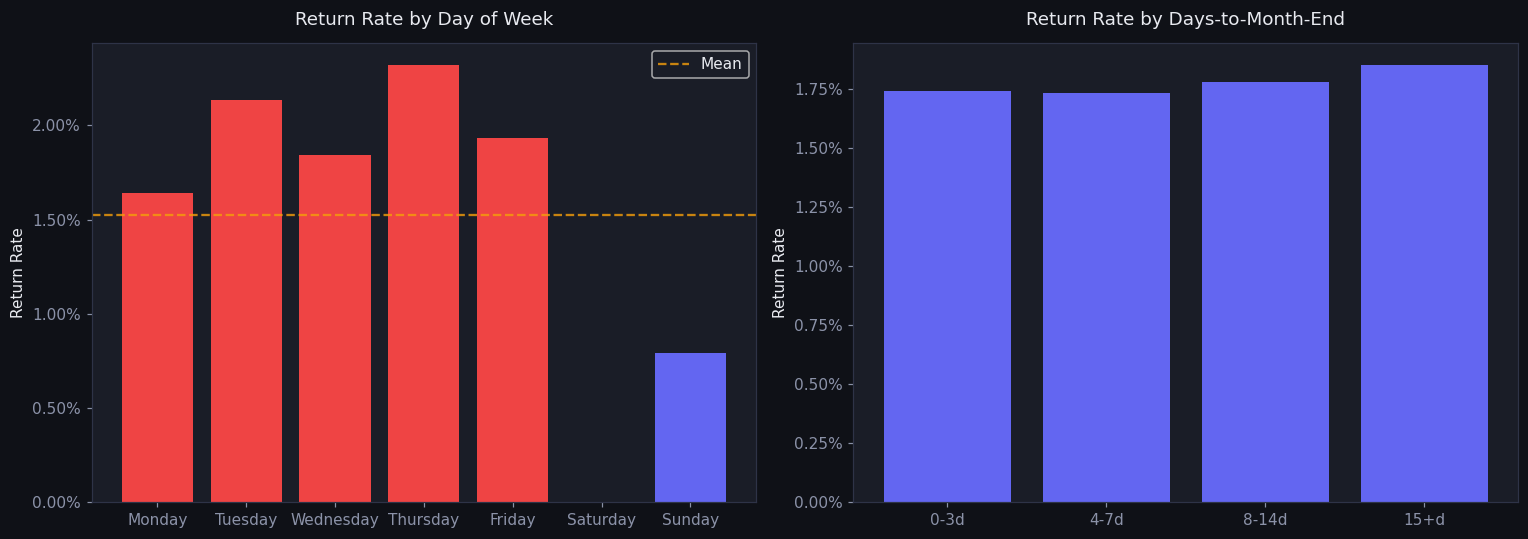

              total  returns  return_rate
day_of_week                              
Monday       189084     3102     0.016405
Tuesday      196626     4201     0.021365
Wednesday    185051     3407     0.018411
Thursday     203149     4711     0.023190
Friday       153803     2969     0.019304
Saturday        402        0     0.000000
Sunday       139256     1104     0.007928


In [6]:
df['day_of_week'] = df['invoice_date'].dt.day_name()
df['hour'] = df['invoice_date'].dt.hour
df['month'] = df['invoice_date'].dt.to_period('M').astype(str)
df['day_of_month'] = df['invoice_date'].dt.day
df['days_in_month'] = df['invoice_date'].dt.days_in_month
df['month_end_proximity'] = df['days_in_month'] - df['day_of_month']

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_stats = (
    df.groupby('day_of_week').agg(
        total=('is_return','count'),
        returns=('is_return','sum')
    ).reindex(dow_order)
)
dow_stats['return_rate'] = dow_stats['returns'] / dow_stats['total']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#ef4444' if r > dow_stats['return_rate'].mean() else '#6366f1'
          for r in dow_stats['return_rate']]
axes[0].bar(dow_stats.index, dow_stats['return_rate'], color=colors)
axes[0].set_title('Return Rate by Day of Week', pad=12)
axes[0].set_ylabel('Return Rate')
axes[0].axhline(dow_stats['return_rate'].mean(), color='#f59e0b', linestyle='--', alpha=0.8, label='Mean')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Month-end proximity binned
df['mep_bin'] = pd.cut(df['month_end_proximity'], bins=[0,3,7,14,31], labels=['0-3d','4-7d','8-14d','15+d'])
mep_stats = df.groupby('mep_bin', observed=True).agg(return_rate=('is_return','mean'))
axes[1].bar(mep_stats.index.astype(str), mep_stats['return_rate'], color='#6366f1')
axes[1].set_title('Return Rate by Days-to-Month-End', pad=12)
axes[1].set_ylabel('Return Rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/01_returns_by_time.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(dow_stats[['total','returns','return_rate']].to_string())

## 4. Returns by country and volume over time

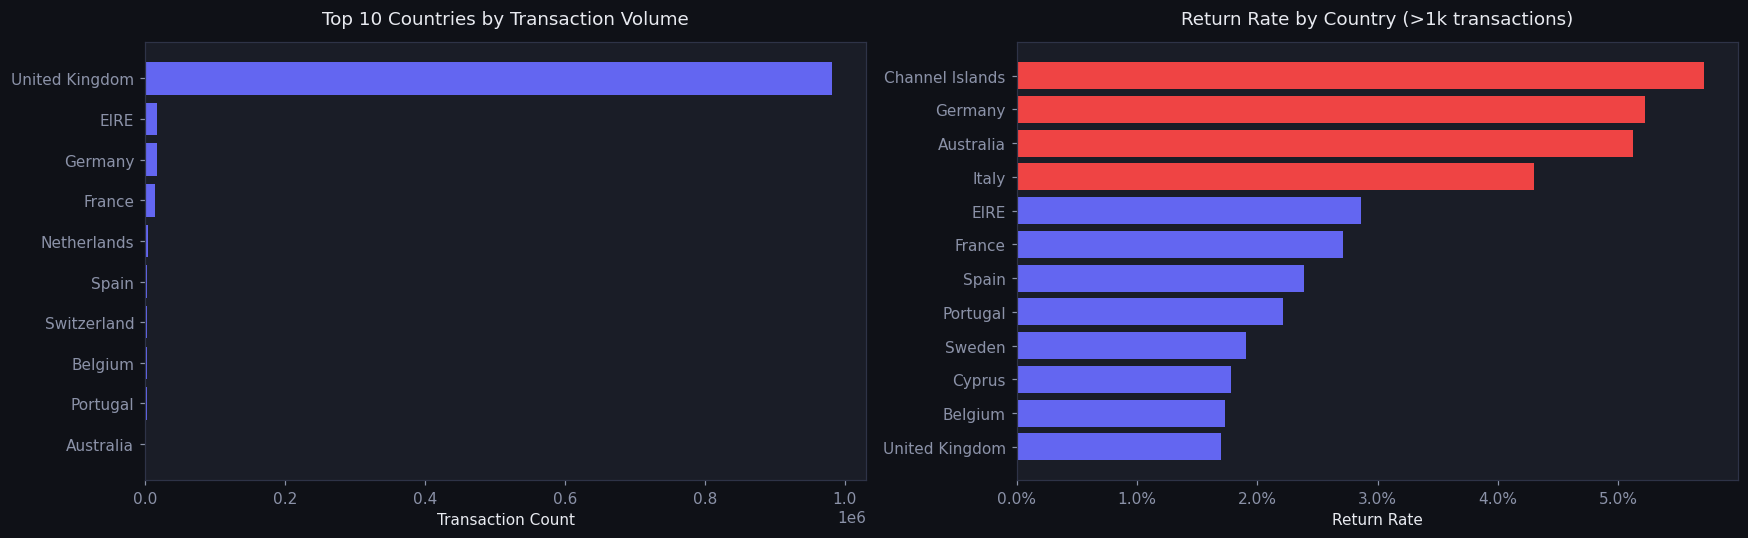

                  total  returns  return_rate
country                                      
United Kingdom   981330    16650     0.016967
EIRE              17866      512     0.028658
Germany           17624      921     0.052258
France            14330      389     0.027146
Netherlands        5140       47     0.009144
Spain              3811       91     0.023878
Switzerland        3189       52     0.016306
Belgium            3123       54     0.017291
Portugal           2620       58     0.022137
Australia          1913       98     0.051228
Channel Islands    1664       95     0.057091
Italy              1534       66     0.043025
Norway             1455       18     0.012371
Sweden             1364       26     0.019062
Cyprus             1176       21     0.017857


In [7]:
country_stats = (
    df.groupby('country').agg(
        total=('is_return','count'),
        returns=('is_return','sum')
    )
    .assign(return_rate=lambda x: x['returns']/x['total'])
    .sort_values('total', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top = country_stats.head(10)
axes[0].barh(top.index[::-1], top['total'][::-1], color='#6366f1')
axes[0].set_title('Top 10 Countries by Transaction Volume', pad=12)
axes[0].set_xlabel('Transaction Count')

# Return rate for countries with >1000 transactions
sig = country_stats[country_stats['total'] > 1000].sort_values('return_rate', ascending=False).head(12)
colors2 = ['#ef4444' if r > sig['return_rate'].mean() else '#6366f1' for r in sig['return_rate']]
axes[1].barh(sig.index[::-1], sig['return_rate'][::-1], color=colors2[::-1])
axes[1].set_title('Return Rate by Country (>1k transactions)', pad=12)
axes[1].set_xlabel('Return Rate')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('../figures/01_returns_by_country.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(country_stats.to_string())

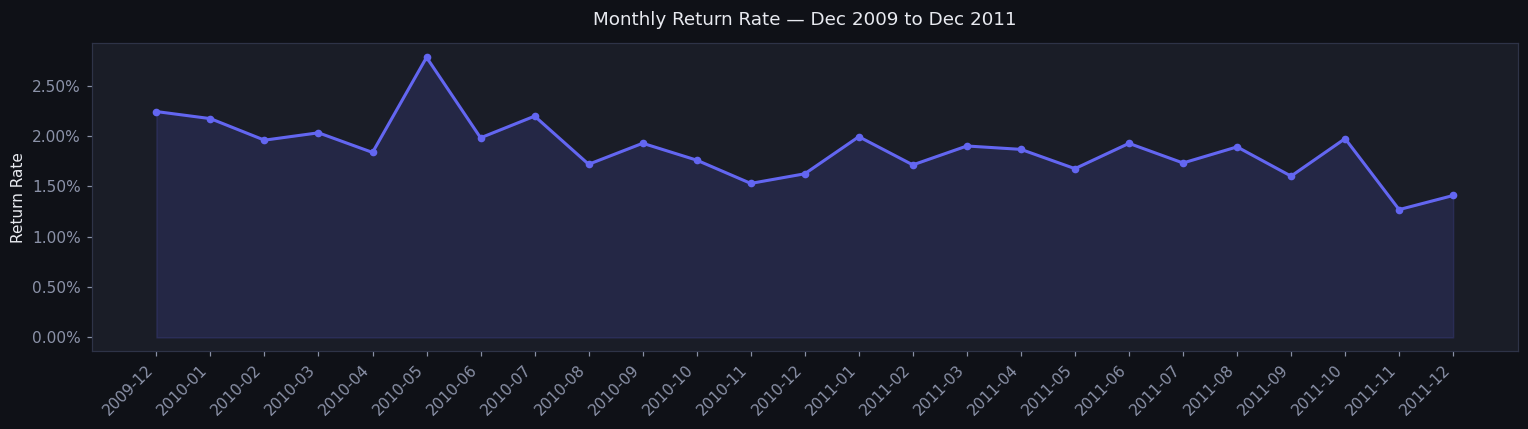

In [8]:
# Monthly return rate trend
monthly = (
    df.groupby('month').agg(
        total=('is_return','count'),
        returns=('is_return','sum')
    ).assign(return_rate=lambda x: x['returns']/x['total'])
)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(monthly.index, monthly['return_rate'], color='#6366f1', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly.index, monthly['return_rate'], alpha=0.15, color='#6366f1')
ax.set_title('Monthly Return Rate — Dec 2009 to Dec 2011', pad=12)
ax.set_ylabel('Return Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/01_monthly_return_rate.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 5. Top-decile excessive returners — qualitative profile

In [9]:
# Customer-level summary for labeled customers only
cust_df = df.dropna(subset=['customer_id'])

purchases = cust_df[cust_df['is_return'] == 0]
returns = cust_df[cust_df['is_return'] == 1]

cust_purchase = (
    purchases.groupby('customer_id').agg(
        total_orders=('invoice_no','nunique'),
        total_revenue=('revenue','sum'),
    )
)
cust_return = (
    returns.groupby('customer_id').agg(
        total_return_orders=('invoice_no','nunique'),
        total_return_value=('revenue', lambda x: abs(x.sum())),
    )
)
cust = cust_purchase.join(cust_return, how='left').fillna(0)
cust['return_value_ratio'] = cust['total_return_value'] / cust['total_revenue'].clip(lower=1)
cust['lifetime_return_rate'] = cust['total_return_orders'] / cust['total_orders'].clip(lower=1)

print(f'Customers with purchase history: {len(cust):,}')
print(f'Customers with any return: {(cust["total_return_orders"] > 0).sum():,} ({(cust["total_return_orders"] > 0).mean()*100:.1f}%)')

top_decile = cust.nlargest(int(len(cust)*0.10), 'return_value_ratio')
bottom_90pct = cust[~cust.index.isin(top_decile.index)]

print()
print('=== Top-Decile Returners vs. Bottom 90% ===')
compare = pd.DataFrame({
    'Top 10% (Returners)': [
        f"{top_decile['return_value_ratio'].mean():.1%}",
        f"{top_decile['lifetime_return_rate'].mean():.1%}",
        f"£{top_decile['total_revenue'].mean():,.0f}",
        f"{top_decile['total_orders'].mean():.0f}",
        f"£{top_decile['total_return_value'].mean():,.0f}",
    ],
    'Bottom 90%': [
        f"{bottom_90pct['return_value_ratio'].mean():.1%}",
        f"{bottom_90pct['lifetime_return_rate'].mean():.1%}",
        f"£{bottom_90pct['total_revenue'].mean():,.0f}",
        f"{bottom_90pct['total_orders'].mean():.0f}",
        f"£{bottom_90pct['total_return_value'].mean():,.0f}",
    ]
}, index=['Return Value Ratio','Return Rate','Avg Revenue','Avg Orders','Avg Return Value'])
print(compare.to_string())

Customers with purchase history: 5,881
Customers with any return: 2,511 (42.7%)

=== Top-Decile Returners vs. Bottom 90% ===
                   Top 10% (Returners) Bottom 90%
Return Value Ratio               26.7%       0.7%
Return Rate                      70.2%      13.6%
Avg Revenue                     £4,483     £2,854
Avg Orders                           8          6
Avg Return Value                £1,363        £44


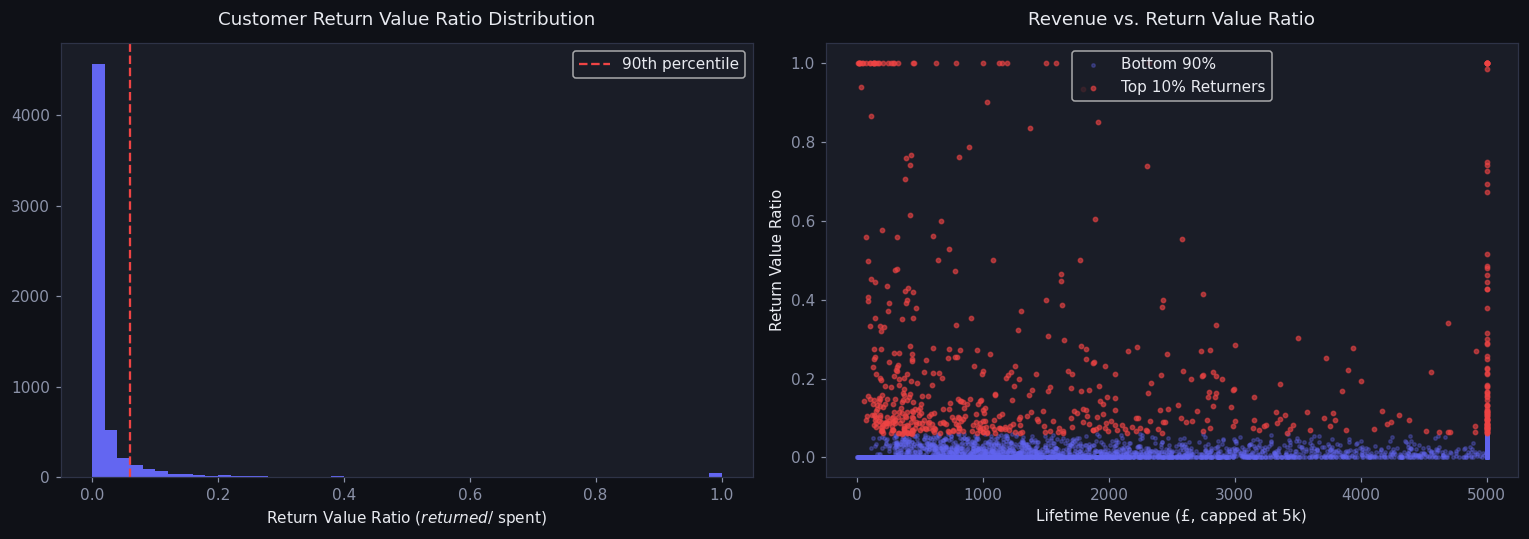

In [10]:
# Distribution of return_value_ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cust['return_value_ratio'].clip(0, 1), bins=50, color='#6366f1', edgecolor='none')
axes[0].axvline(cust['return_value_ratio'].quantile(0.90), color='#ef4444', linestyle='--', label='90th percentile')
axes[0].set_title('Customer Return Value Ratio Distribution', pad=12)
axes[0].set_xlabel('Return Value Ratio ($ returned / $ spent)')
axes[0].legend()

axes[1].scatter(
    bottom_90pct['total_revenue'].clip(0, 5000),
    bottom_90pct['return_value_ratio'].clip(0, 1),
    alpha=0.3, s=5, color='#6366f1', label='Bottom 90%'
)
axes[1].scatter(
    top_decile['total_revenue'].clip(0, 5000),
    top_decile['return_value_ratio'].clip(0, 1),
    alpha=0.6, s=8, color='#ef4444', label='Top 10% Returners'
)
axes[1].set_title('Revenue vs. Return Value Ratio', pad=12)
axes[1].set_xlabel('Lifetime Revenue (£, capped at 5k)')
axes[1].set_ylabel('Return Value Ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/01_returner_profile.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 6. Product categories with highest return rates

In [11]:
# Product-level return rate (stock_code level)
prod_stats = (
    df.groupby('stock_code').agg(
        total=('invoice_no','count'),
        returns=('is_return','sum'),
        description=('description', lambda x: x.dropna().mode().iloc[0] if len(x.dropna()) > 0 else 'Unknown')
    ).assign(return_rate=lambda x: x['returns'] / x['total'].clip(lower=1))
)

# Filter to products with enough volume to be meaningful
sig_prods = prod_stats[prod_stats['total'] >= 50].sort_values('return_rate', ascending=False)

print(f'Products with ≥50 transactions: {len(sig_prods):,}')
print('\nTop 20 highest return-rate products (min 50 transactions):')
print(sig_prods[['description','total','returns','return_rate']].head(20).to_string())

print('\n\nBottom 20 (lowest return rate — most reliable):')
print(sig_prods[['description','total','returns','return_rate']].tail(20).to_string())

Products with ≥50 transactions: 3,084

Top 20 highest return-rate products (min 50 transactions):
                                      description  total  returns  return_rate
stock_code                                                                    
D                                        Discount    177      172     0.971751
S                                         SAMPLES    104      101     0.971154
BANK CHARGES                         Bank Charges    102       67     0.656863
ADJUST        Adjustment by john on 26/01/2010 16     67       31     0.462687
79323B                        BLACK CHERRY LIGHTS    112       51     0.455357
M                                          Manual   1421      538     0.378607
79323GR                       GREEN CHERRY LIGHTS    123       37     0.300813
79323G                        GOLD  CHERRY LIGHTS     90       26     0.288889
79323S                       SILVER CHERRY LIGHTS     81       23     0.283951
79323W                        WHI

## 7. Missing CustomerID analysis

In [12]:
n_missing_cust = df['customer_id'].isnull().sum()
pct_missing = n_missing_cust / len(df) * 100

missing_df = df[df['customer_id'].isnull()]
labeled_df = df[df['customer_id'].notna()]

print('=== Missing CustomerID Analysis ===')
print(f'Rows with missing CustomerID:  {n_missing_cust:,} ({pct_missing:.1f}%)')
print(f'Rows with CustomerID:          {len(labeled_df):,} ({100-pct_missing:.1f}%)')
print()
print(f'Return rate in MISSING:        {missing_df["is_return"].mean():.1%}')
print(f'Return rate in LABELED:        {labeled_df["is_return"].mean():.1%}')
print()
print('Implication: missing-CustomerID rows are KEPT for transaction-level models')
print('but DROP OUT of customer-level aggregations (anomaly, segmentation).')
print('The classifier can be trained on all rows; anomaly/segmentation on labeled rows only.')

=== Missing CustomerID Analysis ===
Rows with missing CustomerID:  243,007 (22.8%)
Rows with CustomerID:          824,364 (77.2%)

Return rate in MISSING:        0.3%
Return rate in LABELED:        2.3%

Implication: missing-CustomerID rows are KEPT for transaction-level models
but DROP OUT of customer-level aggregations (anomaly, segmentation).
The classifier can be trained on all rows; anomaly/segmentation on labeled rows only.


## 8. EDA Summary — Key Findings

In [13]:
# Save key numbers to a dict for use in later notebooks
eda_summary = {
    'n_total': int(n_total),
    'n_returns': int(n_returns),
    'return_tx_pct': float(return_tx_pct),
    'return_rev_pct': float(return_rev_pct),
    'n_labeled_customers': int(len(cust)),
    'pct_missing_customer_id': float(pct_missing),
    'top_decile_threshold': float(cust['return_value_ratio'].quantile(0.90)),
}

print('=== EDA Key Findings ===')
for k, v in eda_summary.items():
    if isinstance(v, float):
        print(f'  {k:<35} {v:.3f}')
    else:
        print(f'  {k:<35} {v:,}')

import json, os
os.makedirs('../data/processed', exist_ok=True)
with open('../data/processed/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)
print('\nSaved to data/processed/eda_summary.json')
print('\nFigures saved to figures/')

=== EDA Key Findings ===
  n_total                             1,067,371
  n_returns                           19,494
  return_tx_pct                       1.826
  return_rev_pct                      7.283
  n_labeled_customers                 5,881
  pct_missing_customer_id             22.767
  top_decile_threshold                0.060

Saved to data/processed/eda_summary.json

Figures saved to figures/
